# Statistical Analysis of Nepal Weather Data

In this notebook we look at the Nepal climate dataset across different districts from 1981 to 2019. We calculate basic descriptive statistics like mean, median, skewness, variance, and check for outliers using IQR and Z-score.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## Loading Data

Loading the dataset and checking its shape and columns.

In [18]:
# Load daily climate data
csv_path = 'dataset/dailyclimate.csv'
df = pd.read_csv(csv_path, skiprows=lambda i: i > 0 and i % 10 != 0)

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print("Dataset shape:", df.shape)
print("Districts count:", df['District'].nunique())
df.head()

Dataset shape: (88312, 22)
Districts count: 62


,Date,District,Latitude,Longitude,Precip,Pressure,Humidity_2m,RH_2m,Temp_2m,WetBulbTemp_2m,...,TempRange_2m,EarthSkinTemp,WindSpeed_10m,MaxWindSpeed_10m,MinWindSpeed_10m,WindSpeedRange_10m,WindSpeed_50m,MaxWindSpeed_50m,MinWindSpeed_50m,WindSpeedRange_50m
0,1981-01-10,Arghakhanchi,27.9,83.2,0.00,94.05,4.68,51.00,11.77,1.84,...,10.84,9.68,1.62,2.77,0.91,1.86,2.02,2.74,1.27,1.47
1,1981-01-20,Arghakhanchi,27.9,83.2,0.00,93.77,5.10,48.79,13.72,3.05,...,11.99,11.96,2.25,4.52,0.22,4.31,3.04,5.03,0.68,4.35
2,1981-01-30,Arghakhanchi,27.9,83.2,0.00,93.47,6.69,61.26,14.33,6.86,...,7.95,12.88,1.61,2.68,0.67,2.01,2.15,3.12,0.74,2.38
3,1981-02-09,Arghakhanchi,27.9,83.2,0.02,93.57,5.02,45.73,14.45,2.83,...,10.81,12.82,2.57,4.50,0.61,3.89,3.23,4.92,0.89,4.03
4,1981-02-19,Arghakhanchi,27.9,83.2,0.00,93.50,4.72,35.76,17.33,1.87,...,14.29,15.74,2.48,4.15,1.52,2.64,3.35,5.17,1.22,3.95


In [19]:
# Summary statistics for main continuous columns
features = ['Temp_2m', 'Humidity_2m', 'Precip', 'Pressure', 'WindSpeed_10m']
df[features].describe()

,Temp_2m,Humidity_2m,Precip,Pressure,WindSpeed_10m
count,88312.000000,88312.000000,88312.000000,88312.000000,88312.000000
mean,15.811742,8.489998,2.411240,82.895835,2.370740
std,9.173594,5.425575,5.977929,10.708629,0.685702
min,-24.180000,0.330000,0.000000,54.980000,0.820000
25%,10.080000,3.910000,0.000000,77.680000,1.900000
50%,16.720000,6.770000,0.050000,83.720000,2.260000
75%,22.500000,13.170000,1.870000,92.740000,2.700000
max,37.750000,22.360000,121.590000,100.220000,13.500000


## Central Tendency

Here we find the mean, median, and mode for key weather variables to see the central values and check if mean and median are close.

In [20]:
# Mean, Median and Mode
features = ['Temp_2m', 'Humidity_2m', 'Precip', 'Pressure', 'WindSpeed_10m']

means = df[features].mean()
medians = df[features].median()
modes = df[features].mode().iloc[0]

summary_ct = pd.DataFrame({'Mean': means, 'Median': medians, 'Mode': modes})
summary_ct

,Mean,Median,Mode
Temp_2m,15.811742,16.72,17.43
Humidity_2m,8.489998,6.77,3.94
Precip,2.411240,0.05,0.00
Pressure,82.895835,83.72,92.84
WindSpeed_10m,2.370740,2.26,1.90


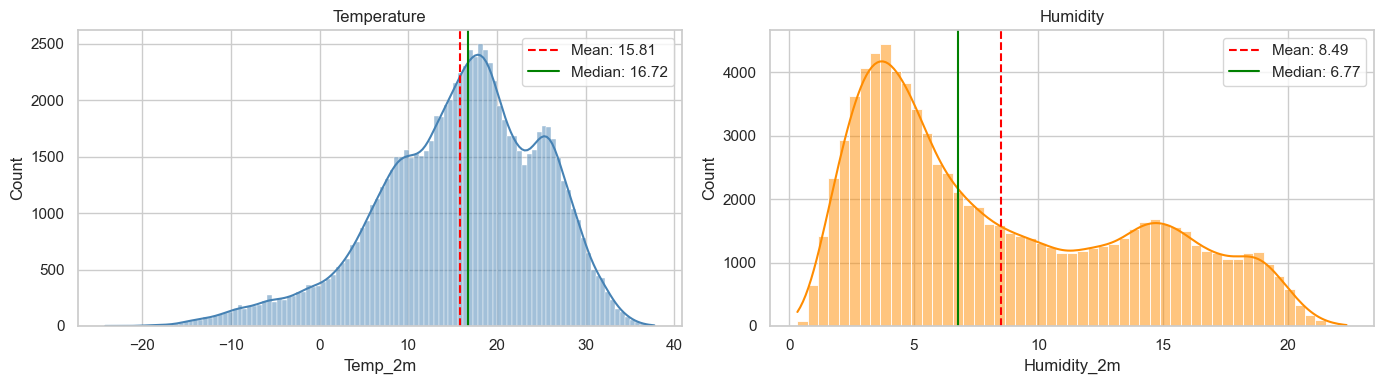

In [21]:
# Plotting mean and median on temperature and humidity distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['Temp_2m'], kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(df['Temp_2m'].mean(), color='red', linestyle='--', label=f"Mean: {df['Temp_2m'].mean():.2f}")
axes[0].axvline(df['Temp_2m'].median(), color='green', linestyle='-', label=f"Median: {df['Temp_2m'].median():.2f}")
axes[0].set_title("Temperature")
axes[0].legend()

sns.histplot(df['Humidity_2m'], kde=True, ax=axes[1], color='darkorange')
axes[1].axvline(df['Humidity_2m'].mean(), color='red', linestyle='--', label=f"Mean: {df['Humidity_2m'].mean():.2f}")
axes[1].axvline(df['Humidity_2m'].median(), color='green', linestyle='-', label=f"Median: {df['Humidity_2m'].median():.2f}")
axes[1].set_title("Humidity")
axes[1].legend()

plt.tight_layout()
plt.show()

## Measures of Spread

Checking how spread out the weather readings are using range, variance, standard deviation, and mean absolute deviation.

In [22]:
# Range, Variance, Std Dev and MAD
features = ['Temp_2m', 'Humidity_2m', 'Precip', 'Pressure', 'WindSpeed_10m']

spread_df = pd.DataFrame({
    'Range': df[features].max() - df[features].min(),
    'Variance': df[features].var(),
    'Std Dev': df[features].std(),
    'MAD': (df[features] - df[features].mean()).abs().mean()
})
spread_df

,Range,Variance,Std Dev,MAD
Temp_2m,61.93,84.154833,9.173594,7.259492
Humidity_2m,22.03,29.436866,5.425575,4.707587
Precip,121.59,35.735631,5.977929,3.316899
Pressure,45.24,114.674725,10.708629,8.684129
WindSpeed_10m,12.68,0.470188,0.685702,0.507203


## Skewness and Kurtosis

Checking shape of distributions. Precipitation has a large positive skew because most days have 0 or little rain while some days have heavy monsoon rain.

In [23]:
# Skewness and Kurtosis
features = ['Temp_2m', 'Humidity_2m', 'Precip', 'Pressure', 'WindSpeed_10m']

shape_df = pd.DataFrame({
    'Skewness': df[features].skew().round(3),
    'Kurtosis': df[features].kurtosis().round(3)
})
shape_df

,Skewness,Kurtosis
Temp_2m,-0.584,0.271
Humidity_2m,0.582,-0.937
Precip,5.161,41.597
Pressure,-0.652,-0.274
WindSpeed_10m,1.718,7.187


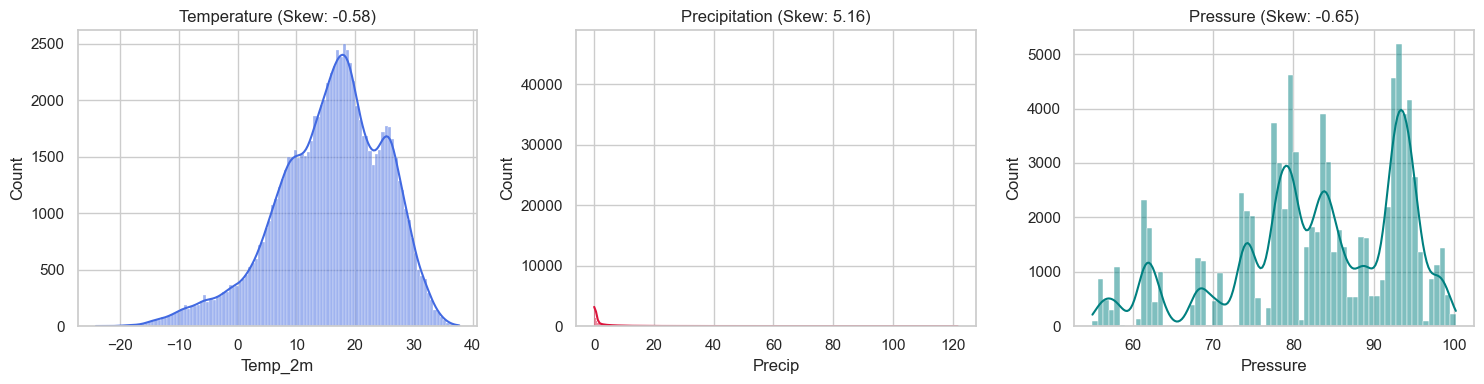

In [24]:
# Plotting distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['Temp_2m'], kde=True, ax=axes[0], color='royalblue')
axes[0].set_title(f"Temperature (Skew: {df['Temp_2m'].skew():.2f})")

sns.histplot(df['Precip'], kde=True, ax=axes[1], color='crimson')
axes[1].set_title(f"Precipitation (Skew: {df['Precip'].skew():.2f})")

sns.histplot(df['Pressure'], kde=True, ax=axes[2], color='teal')
axes[2].set_title(f"Pressure (Skew: {df['Pressure'].skew():.2f})")

plt.tight_layout()
plt.show()

## Covariance and Correlation

Checking relationships between weather features. High correlation is seen between temperature and earth skin temperature.

In [25]:
# Covariance and correlation
features = ['Temp_2m', 'Humidity_2m', 'Precip', 'Pressure', 'WindSpeed_10m', 'EarthSkinTemp']

print("Covariance:")
print(df[features].cov().round(2))

print("\nCorrelation:")
print(df[features].corr().round(2))

Covariance:
               Temp_2m  Humidity_2m  Precip  Pressure  WindSpeed_10m  \
Temp_2m          84.15        31.91   10.74     75.85           0.44   
Humidity_2m      31.91        29.44   14.98     18.54          -0.19   
Precip           10.74        14.98   35.74      3.61           0.08   
Pressure         75.85        18.54    3.61    114.67          -0.83   
WindSpeed_10m     0.44        -0.19    0.08     -0.83           0.47   
EarthSkinTemp    89.98        36.33   12.68     73.56           0.89   

               EarthSkinTemp  
Temp_2m                89.98  
Humidity_2m            36.33  
Precip                 12.68  
Pressure               73.56  
WindSpeed_10m           0.89  
EarthSkinTemp          98.51  

Correlation:
               Temp_2m  Humidity_2m  Precip  Pressure  WindSpeed_10m  \
Temp_2m           1.00         0.64    0.20      0.77           0.07   
Humidity_2m       0.64         1.00    0.46      0.32          -0.05   
Precip            0.20         0.46 

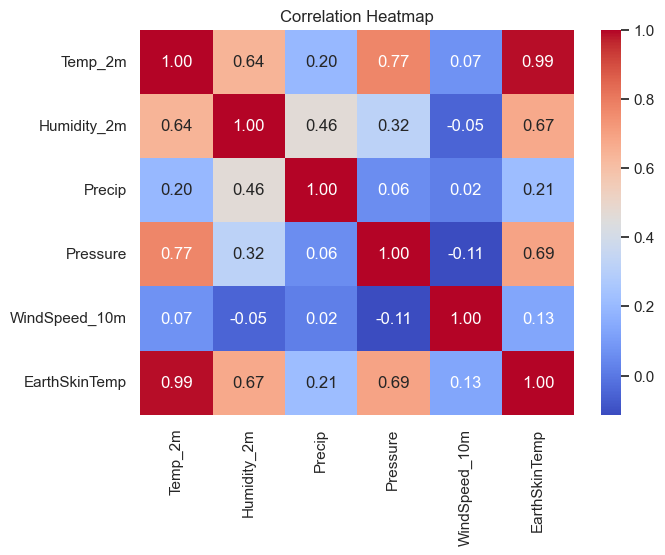

In [26]:
# Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

## Outlier Detection

Checking outliers using IQR and Z-score methods. Rain and wind have some extreme values due to storms and monsoon seasons.

In [27]:
# IQR Outlier Detection
def check_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    outliers = series[(series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)]
    return len(outliers), round((len(outliers) / len(series)) * 100, 2)

for col in ['Temp_2m', 'Precip', 'WindSpeed_10m', 'Pressure']:
    count, pct = check_iqr(df[col])
    print(f"{col:15s} Outliers: {count:6d} ({pct:.2f}%)")

Temp_2m         Outliers:   1250 (1.42%)
Precip          Outliers:  13363 (15.13%)
WindSpeed_10m   Outliers:   2628 (2.98%)
Pressure        Outliers:      4 (0.00%)


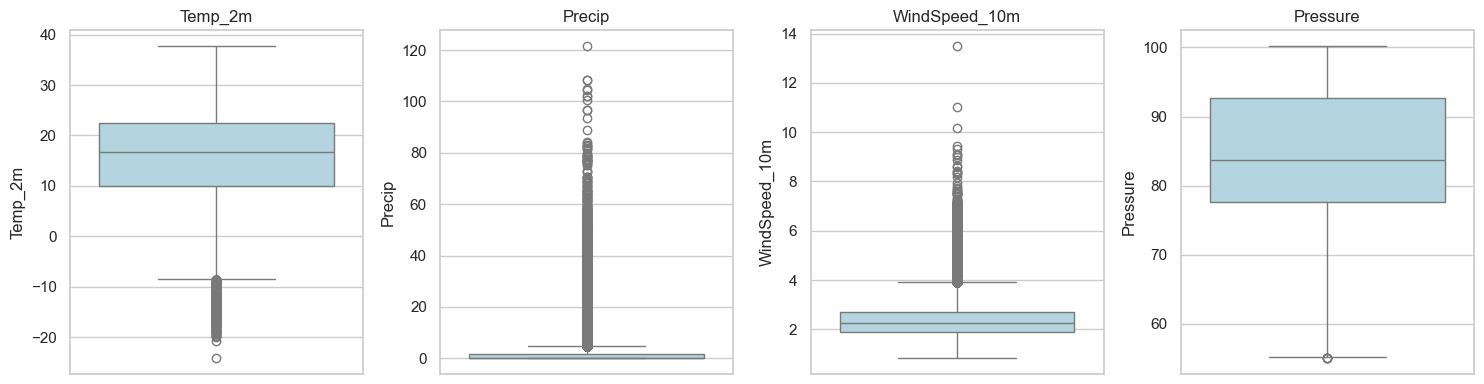

In [28]:
# Boxplots
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
cols = ['Temp_2m', 'Precip', 'WindSpeed_10m', 'Pressure']

for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## Summary

The average temperature in Nepal across these years is around 18.5°C. Precipitation is skewed due to dry winters and heavy rainy seasons. We will use scaling and outlier handling in machine learning.